## Heart murmur detection - Data processing pipeline 

### 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import ast
import os
from scipy.io import wavfile
import matplotlib.pyplot as plt
import sklearn

### 2. Load data
- Note: Table1 is in raw_data_EDA.ipynb
#### 2.1 Load Cohort information

In [2]:
cohort = pd.read_csv('cohort.csv')
cohort['recordings'] = cohort['recordings'].apply(ast.literal_eval)
print(len(cohort))
print(cohort['Murmur'].value_counts())

942
Murmur
Absent     695
Present    179
Unknown     68
Name: count, dtype: int64


There are four data file types in the dataset (per subject):

1. A wave recording file (binary .wav format) per auscultation location for each subject, which contains the heart sound data
2. A header file (text .hea format) describing the .wav file using the standard WFDB format [8]
3. A segmentation data file (text .tsv format) per auscultation location for all subjects, which contains segmentation information regarding the start and end points of the fundamental heart sounds S1 and S2
4. A subject description text file (text .txt format) per subject, where the name of the file corresponds to the subject ID. Demographic data such as weight, height, sex, age group and pregnancy status as well as a detailed description of murmur events are provided in this file.

#### 2.2 Load recordings and segmentation files for whole cohort


In [3]:
DATA_DIR = '1.0.3/training_data'

# each patient has multiple recordings along with a header file
def load_wavfile(wave_filename):
    full_path = os.path.join(DATA_DIR, wave_filename)
    sample_rate, audio = wavfile.read(full_path)
    return sample_rate, audio

# s1, s2 annotations
def load_segmentation(tsv_filename):
    full_path = os.path.join(DATA_DIR, tsv_filename)
    segmentation = pd.read_csv(full_path, sep='\t', header=None, names=['start', 'end', 'label'])
    return segmentation


In [4]:
def load_all_data(cohort):
    data = []
    for _, row in cohort.iterrows():
        patient_id = row['patient_id']
        for recording in row['recordings']:
            location = recording['location']
            wav_file = recording['wav_file']
            tsv_file = recording['tsv_file']

            sample_rate, audio = load_wavfile(wav_file)
            segmentation = load_segmentation(tsv_file)
            data.append({
                'patient_id': patient_id,
                'location': location,
                'sample_rate': sample_rate,
                'audio': audio,
                'audio_length': len(audio) / sample_rate,
                'segmentation': segmentation
            })
    return data

We will exclude recordings that came from Phc ("other auscultation location").

There are only 4 of those patients in the entire cohort.

In [5]:
# value counts of auscultation locations
cohort['recordings'].apply(lambda x: [rec['location'] for rec in x]).explode().value_counts()

recordings
MV     861
AV     800
PV     766
TV     732
Phc      4
Name: count, dtype: int64

In [6]:
# removing those with Phc recordings
cohort = cohort[~cohort['recordings'].apply(lambda x: any(rec['location'] == 'Phc' for rec in x))]
print(len(cohort))

939


#### 2.3 Load patient demographic metadata
age, sex, height, weight, pregnancy status: stored in each of their subject description text files, but also same information is stored in cohort.csv. 

I am using the cohort.csv to extract these for simplicity but will revisit in case there are conflicts


In [7]:
# adding in demographic data from the subject description text files - this is in cohort.csv

def load_demographics(cohort):
    demographics = []
    for _, row in cohort.iterrows():
        patient_id = row['patient_id']
        age = row['Age']
        sex = row['Sex']
        murmur = row['Murmur']
        outcome = row['Outcome']
        demographics.append({
            'patient_id': patient_id,
            'age': age,
            'sex': sex,
            'murmur': murmur,
            'outcome': outcome
        })
    return demographics

### 3. Merge and explore data
Create final dataframe with all features and recordings

In [8]:
all_data = load_all_data(cohort)
demographics = load_demographics(cohort)
# create final dataframe with all features and recordings
final_df = pd.DataFrame(all_data)
demographics_df = pd.DataFrame(demographics)
final_df = final_df.merge(demographics_df, on='patient_id')


In [9]:
final_df.head()

,patient_id,location,sample_rate,audio,audio_length,segmentation,age,sex,murmur,outcome
0,85210,AV,4000,"[-17112, -11475, -5078, 4119, 11855, 10891, 41...",20.656,start end label 0 0.00000...,Child,Female,Absent,Normal
1,85210,PV,4000,"[221, 184, 449, 349, 429, 384, 38, 114, 373, 4...",20.864,start end label 0 0.00000...,Child,Female,Absent,Normal
2,85210,TV,4000,"[-831, 689, 6470, 13741, 12429, 300, -8294, -4...",31.552,start end label 0 0.00000...,Child,Female,Absent,Normal
3,85210,MV,4000,"[229, -541, -933, -870, -96, 243, -45, -1176, ...",21.696,start end label 0 0.000000...,Child,Female,Absent,Normal
4,50388,AV,4000,"[287, 34, 452, -104, 147, 417, 85, -2, -125, 1...",27.584,start end label 0 0.18025 ...,Child,Female,Absent,Normal


In [10]:
final_df.shape

(3150, 10)

### 4. Data quality checks
Making sure the data looks reasonably good before moving on
#### 4.1 Plotting one patient's recording as a sample

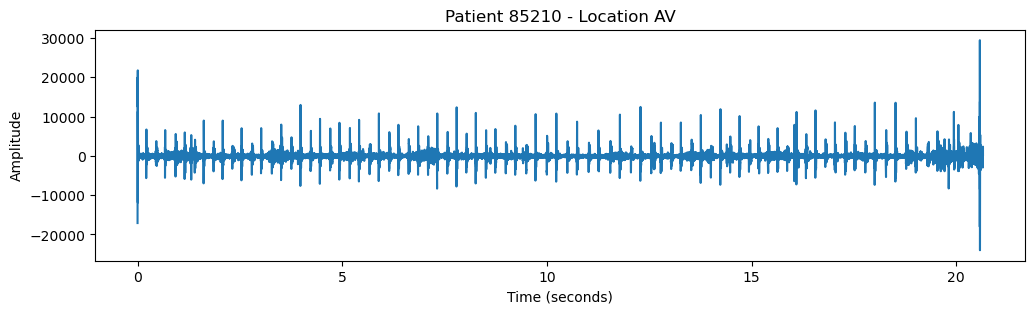

In [11]:
import matplotlib.pyplot as plt

sample_audio = final_df.iloc[0]['audio']
sample_rate = final_df.iloc[0]['sample_rate']
time_axis = np.arange(len(sample_audio)) / sample_rate

plt.figure(figsize=(12, 3))
plt.plot(time_axis, sample_audio)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f"Patient {final_df.iloc[0]['patient_id']} - Location {final_df.iloc[0]['location']}")
plt.show()

#### 4.3 Analyze heartbeat durations
Checking to see if each segment is a reasonable length (should be 0.5-1 seconds)

Heartbeat duration:
  Min: -8.241 sec
  Max: 12.359 sec
  Mean: 0.597 sec
  Median: 0.580 sec
  Std: 0.161 sec


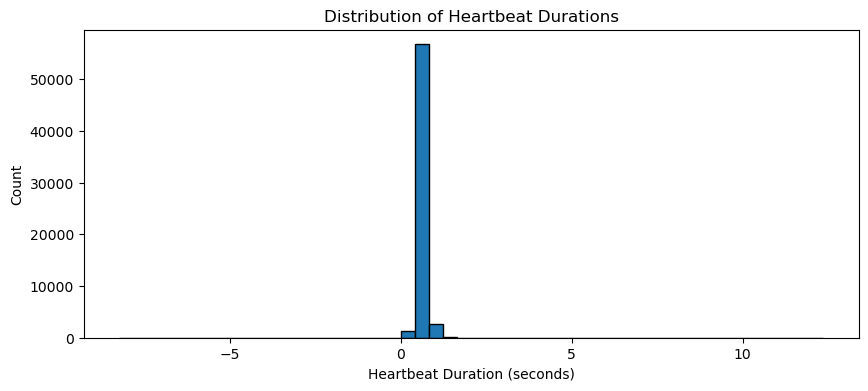

In [12]:
durations = []

for _, row in final_df.iterrows():
    seg = row['segmentation']
    s1_events = seg[seg['label'] == 1]
    s1_times = s1_events['start'].values
    
    if len(s1_times) > 1:
        rr_intervals = np.diff(s1_times)
        durations.extend(rr_intervals)

durations = np.array(durations)

print(f"Heartbeat duration:")
print(f"  Min: {durations.min():.3f} sec")
print(f"  Max: {durations.max():.3f} sec")
print(f"  Mean: {durations.mean():.3f} sec")
print(f"  Median: {np.median(durations):.3f} sec")
print(f"  Std: {durations.std():.3f} sec")

plt.figure(figsize=(10, 4))
plt.hist(durations, bins=50, edgecolor='black')
plt.xlabel('Heartbeat Duration (seconds)')
plt.ylabel('Count')
plt.title('Distribution of Heartbeat Durations')
plt.show()


#### 4.3 Identify/removing outliers
A negative heartbeat duration and a 12-second heartbeat are both impossible. Likely a data quality issue that needs to be looked into. 

Checking where those values came from, and then I will remove those entries that have physically impossible values

In [13]:
duration_records = []

for idx, row in final_df.iterrows():
    seg = row['segmentation']
    s1_events = seg[seg['label'] == 1]
    s1_times = s1_events['start'].values
    
    if len(s1_times) > 1:
        rr_intervals = np.diff(s1_times)
        for i, duration in enumerate(rr_intervals):
            duration_records.append({
                'row_idx': idx,
                's1_time_1': s1_times[i],
                's1_time_2': s1_times[i+1],
                'duration': duration
            })

duration_df = pd.DataFrame(duration_records)

# thresholds for valid heartbeat times 
MIN_VALID = 0.3
MAX_VALID = 2.0

outliers = duration_df[(duration_df['duration'] < MIN_VALID) | (duration_df['duration'] > MAX_VALID)]

print(f"Total durations: {len(duration_df)}")
print(f"Outliers total count: {len(outliers)} ")

print(f"  Negative: {(duration_df['duration'] < 0).sum()}")
print(f"  Too short (0 to 0.3s): {((duration_df['duration'] >= 0) & (duration_df['duration'] < MIN_VALID)).sum()}")
print(f"  Too long (>2s): {(duration_df['duration'] > MAX_VALID).sum()}")

Total durations: 60643
Outliers total count: 57 
  Negative: 2
  Too short (0 to 0.3s): 15
  Too long (>2s): 40


There's not that many outliers so we'll just take those out and carry on

In [14]:
durations_clean = durations[(durations >= MIN_VALID) & (durations <= MAX_VALID)]

In [15]:
durations_clean.mean()

np.float64(0.5953714926880798)

### 5. Extracting individual heartbeats
One heartbeat cycle is 

S1 (1) ->  S2 (2) -> Diastole (3) -> Systole (4) -> S1 (1)

where number inside paranthesis is the label in the dataset. '0' is 'Unknown/padding'

In [16]:
from scipy.signal import resample

target_duration = 1.0
sr = 4000
target_samples = int(target_duration * sr) # 4000 samples

heartbeats = []

for idx, row in final_df.iterrows():
    audio = row['audio']
    sr = row['sample_rate']
    seg = row['segmentation']
    
    s1_events = seg[seg['label'] == 1].sort_values('start')
    s1_times = s1_events['start'].values
    
    if len(s1_times) < 2:
        continue
    
    for i in range(len(s1_times) - 1):  #s1 to next s1
        start_time = s1_times[i]
        end_time = s1_times[i + 1]
        duration = end_time - start_time
        
        if duration < 0.3 or duration > 2.0:
            continue

        start_sample = int(start_time * sr)
        end_sample = int(end_time * sr)
        
        beat_audio = audio[start_sample:end_sample]
        beat_resampled = resample(beat_audio, target_samples)
        
        heartbeats.append({
            'row_idx': idx,
            'patient_id': row['patient_id'],
            'location': row['location'],
            'start_time': start_time,
            'end_time': end_time,
            'original_duration': duration,
            'audio': beat_resampled,
            'murmur': row['murmur'],
            'outcome': row['outcome']
        })

heartbeats_df = pd.DataFrame(heartbeats)

print(f"Extracted {len(heartbeats_df)} heartbeats")

print(f"\nSample counts by murmur presence:")
print(heartbeats_df['murmur'].value_counts())

Extracted 60566 heartbeats

Sample counts by murmur presence:
murmur
Absent     46660
Present    12348
Unknown     1558
Name: count, dtype: int64


### 6. Preparing Final dataset

We have a majority murmur absent class, so there is a class imbalance that will need to be handled down the line. 

For the sake of clarity, we'll remove the unknown class and continue as binary classification.


In [17]:
heartbeats_df = heartbeats_df[heartbeats_df['murmur'] != 'Unknown']

print(heartbeats_df['murmur'].value_counts())

murmur
Absent     46660
Present    12348
Name: count, dtype: int64


In [18]:
heartbeats_df.head()

,row_idx,patient_id,location,start_time,end_time,original_duration,audio,murmur,outcome
0,0,85210,AV,0.440169,0.900169,0.46,"[252.0, 360.76389899787927, 394.1574746596753,...",Absent,Normal
1,0,85210,AV,0.900169,1.360169,0.46,"[-79.9999999999998, -91.77027393605066, -123.2...",Absent,Normal
2,0,85210,AV,1.360169,1.840169,0.48,"[-16.000000000000306, 139.21142651359898, 116....",Absent,Normal
3,0,85210,AV,1.840169,2.300169,0.46,"[-753.0, -853.1204274844623, -823.982905949873...",Absent,Normal
4,0,85210,AV,2.300169,2.760169,0.46,"[-245.0000000000001, -204.63786537443295, -189...",Absent,Normal


### 7. Train/test split
Splitting by patient_id and NOT by heartbeat to prevent data leakage.
Starting with a 80/20 train/test split but should consider validation down the line.

In [19]:
from sklearn.model_selection import train_test_split

patients = heartbeats_df[['patient_id', 'murmur']].drop_duplicates()

train_patients, test_patients = train_test_split(
    patients['patient_id'],
    test_size=0.2,
    stratify=patients['murmur'],
    random_state=42
)

train_df = heartbeats_df[heartbeats_df['patient_id'].isin(train_patients)]
test_df = heartbeats_df[heartbeats_df['patient_id'].isin(test_patients)]

print(f"Train: {len(train_df)} heartbeats from {len(train_patients)} patients")
print(f"Test: {len(test_df)} heartbeats from {len(test_patients)} patients")

print(f"\nTrain murmur distribution:")
print(train_df['murmur'].value_counts(normalize=True))

print(f"\nTest murmur distribution:")
print(test_df['murmur'].value_counts(normalize=True))

Train: 46733 heartbeats from 696 patients
Test: 12275 heartbeats from 175 patients

Train murmur distribution:
murmur
Absent     0.78681
Present    0.21319
Name: proportion, dtype: float64

Test murmur distribution:
murmur
Absent     0.805703
Present    0.194297
Name: proportion, dtype: float64


Similar class distributions in both sets

In [20]:
X_train = np.stack(train_df['audio'].values)
X_test = np.stack(test_df['audio'].values)


y_train = (train_df['murmur'] == 'Present').astype(int).values
y_test = (test_df['murmur'] == 'Present').astype(int).values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (46733, 4000)
X_test shape: (12275, 4000)


Just to keep track of the train/test patient IDs for later use

In [21]:
train_patient_ids = train_df['patient_id'].values
test_patient_ids = test_df['patient_id'].values
print(f"Unique patients in test: {len(np.unique(test_patient_ids))}")
print(f"Unique patients in train: {len(np.unique(train_patient_ids))}")

Unique patients in test: 175
Unique patients in train: 696


In [22]:
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)
np.save('train_patient_ids.npy', train_patient_ids)
np.save('test_patient_ids.npy', test_patient_ids)